Loss: 0.318156
Loss: 0.000023
Loss: 0.000010


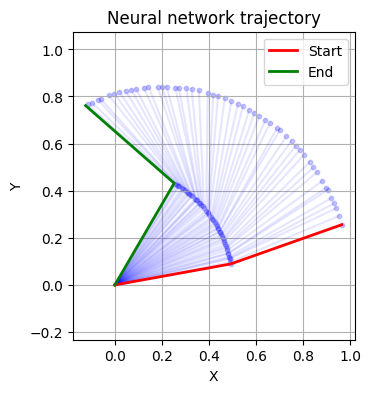

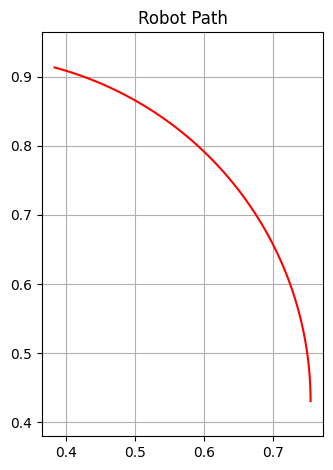

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
import matplotlib.pyplot as plt


N = 100
T = 5.0
dt = T / (N - 1)
L1, L2 = 0.5, 0.5  

def forward_kinematics(q1, q2):
    
    q1_r, q2_r = np.radians(q1), np.radians(q2)
    x1 = L1 * np.cos(q1_r)
    y1 = L1 * np.sin(q1_r)
    x2 = x1 + L2 * np.cos(q1_r + q2_r)
    y2 = y1 + L2 * np.sin(q1_r + q2_r)
    return x1, y1, x2, y2
    

def objective(x):
    q = x.reshape((N, 2))
    v = (q[1:] - q[:-1]) / dt
    return np.sum(v**2)
    
q_start = np.array([0, 0])
q_end = np.array([30, 45]) 
def start_constraint(x):
    q = x.reshape((N, 2))
    return q[0] - q_start

def end_constraint(x):
    q = x.reshape((N, 2))
    return q[-1] - q_end

cons = [
    {'type': 'eq', 'fun': start_constraint},
    {'type': 'eq', 'fun': end_constraint}
]
initial_guess = np.linspace(q_start, q_end, N).flatten()

res = minimize(objective, initial_guess, constraints=cons, method='SLSQP')

q_opt = res.x.reshape((N, 2))
q1_opt = q_opt[:, 0]
q2_opt = q_opt[:, 1]

time = np.linspace(0, T, N)
def coordinate(q1, q2, l1=0.5, l2=0.5):
    a1 = l1 * np.cos(np.radians(q1))
    b1 = l1 * np.sin(np.radians(q1))
    a2 = x1 + l2 * np.cos(np.radians(q1 + q2))
    b2 = y1 + l2 * np.sin(np.radians(q1 + q2))
    return a2, b2

def generate_data(num_samples=100):
    inputs, outputs = [], []
    for _ in range(num_samples):
        qs = np.random.uniform(0, 90, 2)
        qe = np.random.uniform(0, 90, 2)
        res = minimize(objective, np.linspace(qs, qe, N).flatten(), 
                       constraints=[{'type':'eq','fun':lambda x: x.reshape((N,2))[0]-qs},
                                    {'type':'eq','fun':lambda x: x.reshape((N,2))[-1]-qe}], 
                       method='SLSQP')
        if res.success:
            inputs.append(np.concatenate([qs, qe]))
            outputs.append(res.x)
    return torch.tensor(np.array(inputs), dtype=torch.float32), torch.tensor(np.array(outputs), dtype=torch.float32)

X, y = generate_data(200)

class TrajectoryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 200) # Output is N*2 joint angles
        )
    def forward(self, x): return self.net(x)

model = TrajectoryMLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(1001):
    optimizer.zero_grad()
    loss = criterion(model(X/90.0), y/90.0) # Normalized training
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0: print(f"Loss: {loss.item():.6f}")

model.eval()
with torch.no_grad():
   
    test_input = torch.tensor([[10, 10, 60, 80]], dtype=torch.float32)
    pred_angles = (model(test_input/90.0) * 90.0).numpy().reshape(N, 2)
plt.figure(figsize=(8, 4))    
plt.subplot(1,2,1)
for i in range(0, N, 2): 
    x1, y1, x2, y2 = forward_kinematics(pred_angles[i,0], pred_angles[i,1])
   
    plt.plot([0, x1, x2], [0, y1, y2], color='blue', alpha=0.1)   
    plt.scatter([x1, x2], [y1, y2], color='blue', s=10, alpha=0.2)
    
x1s, y1s, x2s, y2s = forward_kinematics(pred_angles[0,0], pred_angles[0,1])
x1e, y1e, x2e, y2e = forward_kinematics(pred_angles[-1,0], pred_angles[-1,1])
plt.plot([0, x1s, x2s], [0, y1s, y2s], 'r-', linewidth=2, label='Start')
plt.plot([0, x1e, x2e], [0, y1e, y2e], 'g-', linewidth=2, label='End')

plt.title("Neural network trajectory")
plt.xlabel("X"); plt.ylabel("Y")
plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()

plt.subplot(1,2,2)
ee_x, ee_y = coordinate(q1_opt, q2_opt)
plt.plot(ee_x, ee_y, 'r-')
plt.title("Robot Path")
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()